### ВСЕМ ПРИВЕЕТ


In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/processed/healthy_bancrupted.csv')
print("df shape:", df.shape)
print("\nПервые строки df:")
print(df.head())

df shape: (31996, 22)

Первые строки df:
    Год  Регистрационный номер  Возраст компании, лет  \
0  2015           1.020101e+12                   34.0   
1  2016           1.020101e+12                   34.0   
2  2017           1.020101e+12                   34.0   
3  2018           1.020101e+12                   34.0   
4  2019           1.020101e+12                   34.0   

                            Вид деятельности/отрасль  Выручка, RUB  \
0  Деятельность по предоставлению мест для кратко...    13289000.0   
1  Деятельность по предоставлению мест для кратко...     9406000.0   
2  Деятельность по предоставлению мест для кратко...     8739000.0   
3  Деятельность по предоставлению мест для кратко...     2565000.0   
4  Деятельность по предоставлению мест для кратко...     2370000.0   

   Коэффициент быстрой ликвидности, %  \
0                              0.0682   
1                              0.0514   
2                              0.6114   
3                              

In [3]:
# Приводим к строке и убираем ".0" в конце, если есть
ogrn_str = df['Регистрационный номер'].astype(str).str.replace(r'\.0$', '', regex=True)

# Считаем длину каждой строки (только цифры — на случай, если где-то есть буквы или пробелы)
lengths = ogrn_str.str.len()

# Уникальные длины + сколько компаний с каждой длиной
print("Уникальные длины ОГРН в df:")
print(lengths.value_counts().sort_index())

# А также просто список уникальных длин
print("\nПросто список уникальных длин:", sorted(lengths.unique()))

Уникальные длины ОГРН в df:
Регистрационный номер
13    31996
Name: count, dtype: int64

Просто список уникальных длин: [13]


In [4]:
region_codes = {
    '01': 'Республика Адыгея',
    '02': 'Республика Башкортостан',
    '03': 'Республика Бурятия',
    '04': 'Республика Алтай',
    '05': 'Республика Дагестан',
    '06': 'Республика Ингушетия',
    '07': 'Кабардино-Балкарская Республика',
    '08': 'Республика Калмыкия',
    '09': 'Карачаево-Черкесская Республика',
    '10': 'Республика Карелия',
    '11': 'Республика Коми',
    '12': 'Республика Марий Эл',
    '13': 'Республика Мордовия',
    '14': 'Республика Саха (Якутия)',
    '15': 'Республика Северная Осетия — Алания',
    '16': 'Республика Татарстан',
    '17': 'Республика Тыва',
    '18': 'Удмуртская Республика',
    '19': 'Республика Хакасия',
    '20': 'Чеченская Республика',     # старый код до 2000 г.
    '21': 'Чувашская Республика',
    '22': 'Алтайский край',
    '23': 'Краснодарский край',
    '24': 'Красноярский край',
    '25': 'Приморский край',
    '26': 'Ставропольский край',
    '27': 'Хабаровский край',
    '28': 'Амурская область',
    '29': 'Архангельская область',
    '30': 'Астраханская область',
    '31': 'Белгородская область',
    '32': 'Брянская область',
    '33': 'Владимирская область',
    '34': 'Волгоградская область',
    '35': 'Вологодская область',
    '36': 'Воронежская область',
    '37': 'Ивановская область',
    '38': 'Иркутская область',
    '39': 'Калининградская область',
    '40': 'Калужская область',
    '41': 'Камчатский край',
    '42': 'Кемеровская область',
    '43': 'Кировская область',
    '44': 'Костромская область',
    '45': 'Курганская область',
    '46': 'Курская область',
    '47': 'Ленинградская область',
    '48': 'Липецкая область',
    '49': 'Магаданская область',
    '50': 'Московская область',
    '51': 'Мурманская область',
    '52': 'Нижегородская область',
    '53': 'Новгородская область',
    '54': 'Новосибирская область',
    '55': 'Омская область',
    '56': 'Оренбургская область',
    '57': 'Орловская область',
    '58': 'Пензенская область',
    '59': 'Пермский край',
    '60': 'Псковская область',
    '61': 'Ростовская область',
    '62': 'Рязанская область',
    '63': 'Самарская область',
    '64': 'Саратовская область',
    '65': 'Сахалинская область',
    '66': 'Свердловская область',
    '67': 'Смоленская область',
    '68': 'Тамбовская область',
    '69': 'Тверская область',
    '70': 'Томская область',
    '71': 'Тульская область',
    '72': 'Тюменская область',
    '73': 'Ульяновская область',
    '74': 'Челябинская область',
    '75': 'Забайкальский край',
    '76': 'Ярославская область',
    '77': 'г. Москва',
    '78': 'г. Санкт-Петербург',
    '79': 'Еврейская автономная область',
    '83': 'Ненецкий АО',
    '86': 'Ханты-Мансийский АО — Югра',
    '87': 'Чукотский АО',
    '89': 'Ямало-Ненецкий АО',
    '91': 'Республика Крым',           # новый код с 2016
    '92': 'г. Севастополь',            # новый код с 2016
    '96': 'Республика Крым',           # старый код (до 2016)
    '98': 'г. Севастополь',            # старый код (до 2016)
    '99': 'Иные территории (включая Байконур)'
}

# Добавляем регион в df
df['ogrn_str'] = df['Регистрационный номер'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(13)

df['region_code'] = df['ogrn_str'].str[3:5]                    # 4-я и 5-я цифры
df['Регион'] = df['region_code'].map(region_codes)

# Проверка
print(df['Регион'].value_counts().head(10))
print(f"\nПокрытие: {df['Регион'].notna().sum()}/{len(df)} (100%)")

Регион
г. Москва                3501
г. Санкт-Петербург       1669
Краснодарский край       1598
Московская область       1389
Ростовская область       1036
Свердловская область      919
Нижегородская область     905
Республика Татарстан      902
Самарская область         820
Воронежская область       741
Name: count, dtype: int64

Покрытие: 31996/31996 (100%)


In [5]:
# 1. Загружаем твой файл ВРП на душу
vrp = pd.read_excel("../data/vrp_souls.xlsx", sheet_name="Лист1", header=None)

# Первая строка — годы, начиная со второй колонки
years = vrp.iloc[0, 1:].astype(int).tolist()      # [2015,2016,...,2023]
vrp_data = vrp.iloc[1:, :].copy()
vrp_data.columns = ['Регион_raw'] + years

# 2. Словарь: название региона → код региона (строго по Росстату 2025)
region_to_code = {
    'Белгородская область': '31',
    'Брянская область': '32',
    'Владимирская область': '33',
    'Воронежская область': '36',
    'Ивановская область': '37',
    'Калужская область': '40',
    'Костромская область': '44',
    'Курская область': '46',
    'Липецкая область': '48',
    'Московская область': '50',
    'Орловская область': '57',
    'Рязанская область': '62',
    'Смоленская область': '67',
    'Тамбовская область': '68',
    'Тверская область': '69',
    'Тульская область': '71',
    'Ярославская область': '76',
    'г.Москва': '77',
    'Республика Карелия': '10',
    'Республика Коми': '11',
    'Архангельская область': '29',           # без НАО тоже 29
    'Вологодская область': '35',
    'Калининградская область': '39',
    'Ленинградская область': '47',
    'Мурманская область': '51',
    'Новгородская область': '53',
    'Псковская область': '60',
    'г.Санкт-Петербург': '78',
    'Республика Адыгея': '01',
    'Республика Калмыкия': '08',
    'Республика Крым': '91',                 # 91 и 96 → оба маппим на 91
    'Краснодарский край': '23',
    'Астраханская область': '30',
    'Волгоградская область': '34',
    'Ростовская область': '61',
    'г.Севастополь': '92',                   # 92 и 98 → оба на 92
    'Республика Дагестан': '05',
    'Республика Ингушетия': '06',
    'Кабардино-Балкарская Республика': '07',
    'Карачаево-Черкесская Республика': '09',
    'Республика Северная Осетия-Алания': '15',
    'Чеченская Республика': '20',
    'Ставропольский край': '26',
    'Республика Башкортостан': '02',
    'Республика Марий Эл': '12',
    'Республика Мордовия': '13',
    'Республика Татарстан': '16',
    'Удмуртская Республика': '18',
    'Чувашская Республика': '21',
    'Пермский край': '59',
    'Кировская область': '43',
    'Нижегородская область': '52',
    'Оренбургская область': '56',
    'Пензенская область': '58',
    'Самарская область': '63',
    'Саратовская область': '64',
    'Ульяновская область': '73',
    'Курганская область': '45',
    'Свердловская область': '66',
    'Тюменская область': '72',               # с АО и без — всё равно 72
    'Челябинская область': '74',
    'Республика Алтай': '04',
    'Республика Тыва': '17',
    'Республика Хакасия': '19',
    'Алтайский край': '22',
    'Красноярский край': '24',
    'Иркутская область': '38',
    'Кемеровская область-Кузбасс': '42',
    'Новосибирская область': '54',
    'Омская область': '55',
    'Томская область': '70',
    'Республика Бурятия': '03',
    'Республика Саха (Якутия)': '14',
    'Забайкальский край': '75',
    'Камчатский край': '41',
    'Приморский край': '25',
    'Хабаровский край': '27',
    'Амурская область': '28',
    'Магаданская область': '49',
    'Сахалинская область': '65',
    'Еврейская автономная область': '79',
    'Чукотский автономный округ': '87',
    'Ненецкий авт. округ': '83',
    'Ханты-Мансийский авт. округ-Югра': '86',
    'Ямало-Ненецкий авт. округ': '89',
}

# 3. Чиним названия в файле ВРП и добавляем код региона
vrp_data['Регион'] = vrp_data['Регион_raw'].str.strip()
vrp_data['region_code'] = vrp_data['Регион'].map(region_to_code)


# Переходим в длинный формат
vrp_long = vrp_data.melt(
    id_vars=['region_code'],
    value_vars=years,
    var_name='Год',
    value_name='ВРП_на_душу'
)

vrp_long = vrp_long.dropna(subset=['region_code'])
vrp_long['Год'] = vrp_long['Год'].astype(int)
vrp_long['ВРП_на_душу'] = pd.to_numeric(vrp_long['ВРП_на_душу'], errors='coerce')

# КЛЮЧЕВОЙ БЛОК: добавляем поддержку старых кодов Крыма и Севастополя
crimea = vrp_long[vrp_long['region_code'] == '91'].copy()
sevastopol = vrp_long[vrp_long['region_code'] == '92'].copy()

crimea['region_code'] = '96'
sevastopol['region_code'] = '98'

vrp_long = pd.concat([vrp_long, crimea, sevastopol], ignore_index=True)

# (опционально) проверка
print("Коды 96 и 98 добавлены:", '96' in vrp_long['region_code'].values, '98' in vrp_long['region_code'].values)

# УДАЛЯЕМ старую колонку (если она есть) — это решает ошибку на 100%
if 'ВРП_на_душу' in df.columns:
    df = df.drop(columns='ВРП_на_душу')

# Теперь мёрдж пройдёт без ошибок
df = df.merge(
    vrp_long[['region_code', 'Год', 'ВРП_на_душу']],
    on=['region_code', 'Год'],
    how='left'
)

# Результат
print(f"Покрытие ВРП на душу: {df['ВРП_на_душу'].notna().sum()}/{len(df)} = {df['ВРП_на_душу'].notna().mean():.5%}")
print("NaN осталось:", df['ВРП_на_душу'].isna().sum())

Коды 96 и 98 добавлены: True True
Покрытие ВРП на душу: 31996/31996 = 100.00000%
NaN осталось: 0


In [6]:
print(df.head())

    Год  Регистрационный номер  Возраст компании, лет  \
0  2015           1.020101e+12                   34.0   
1  2016           1.020101e+12                   34.0   
2  2017           1.020101e+12                   34.0   
3  2018           1.020101e+12                   34.0   
4  2019           1.020101e+12                   34.0   

                            Вид деятельности/отрасль  Выручка, RUB  \
0  Деятельность по предоставлению мест для кратко...    13289000.0   
1  Деятельность по предоставлению мест для кратко...     9406000.0   
2  Деятельность по предоставлению мест для кратко...     8739000.0   
3  Деятельность по предоставлению мест для кратко...     2565000.0   
4  Деятельность по предоставлению мест для кратко...     2370000.0   

   Коэффициент быстрой ликвидности, %  \
0                              0.0682   
1                              0.0514   
2                              0.6114   
3                              0.5672   
4                              

In [7]:
# Убираем все колонки, в названии которых есть "ВРП_на_душу" + суффиксы x/y/old и т.д.
cols_to_drop = [col for col in df.columns if 'ВРП_на_душу' in col and col != 'ВРП_на_душу']
df = df.drop(columns=cols_to_drop)

print("Удалены колонки:", cols_to_drop)
print("Осталась только чистая колонка 'ВРП_на_душу'")

Удалены колонки: []
Осталась только чистая колонка 'ВРП_на_душу'


In [8]:
# Создаём датафрейм с твоими данными
usd_rate = pd.DataFrame({
    'Год': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'USD_RUB_средневзвешенный': [60.96, 67.03, 58.35, 62.71, 64.74, 72.15, 73.65, 68.55, 85.25]
})

# Приводим тип года к int (на всякий случай)
df['Год'] = df['Год'].astype(int)
usd_rate['Год'] = usd_rate['Год'].astype(int)

# Мёрджим
df = df.merge(usd_rate, on='Год', how='left')

print("Курс доллара добавлен успешно!")

Курс доллара добавлен успешно!


In [9]:
# 1. Создаём датафрейм с твоими данными
confidence_index = pd.DataFrame({
    'Год': [2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    'Индекс_предпринимательской_уверенности': [3.3, 0.5, -6.8, -6.8, -4.0, -2.5, -3.0, -19.0, -4.0, -6.8, -1.8, 0.5, 2.3]
})

# Убедимся, что тип года совпадает
df['Год'] = df['Год'].astype(int)
confidence_index['Год'] = confidence_index['Год'].astype(int)

# 2. Мёрджим в основной датафрейм
df = df.merge(confidence_index, on='Год', how='left')


print("Индекс предпринимательской уверенности добавлен!")

Индекс предпринимательской уверенности добавлен!


In [10]:
# Среднегодовая ключевая ставка ЦБ РФ (2015–2023)
key_rate = pd.DataFrame({
    'Год': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'Ключевая_ставка_средняя': [12.54, 10.54, 9.04, 7.42, 7.25, 4.94, 5.98, 11.00, 10.38]
})

# Убеждаемся, что тип года совпадает
df['Год'] = df['Год'].astype(int)
key_rate['Год'] = key_rate['Год'].astype(int)

# Добавляем в основной датафрейм
df = df.merge(key_rate, on='Год', how='left')


print("Ключевая ставка добавлена!")

Ключевая ставка добавлена!


In [11]:
# Создаём датафрейм с МРОТ (актуальное значение на конец года)
mrot_data = pd.DataFrame({
    'Год': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023],
    'МРОТ_на_конец_года': [5965, 6852, 7500, 10661, 11280, 12130, 12792, 14584, 16242]
})


# Приводим типы
mrot_data['Год'] = mrot_data['Год'].astype(int)
df['Год'] = df['Год'].astype(int)

# Мёрджим в основной датафрейм
df = df.merge(mrot_data, on='Год', how='left')

# Проверяем результат
print("МРОТ успешно добавлен!")

МРОТ успешно добавлен!


In [11]:
df.to_csv('macro_data.csv', index=False, encoding='utf-8-sig')

In [12]:
print(df.head())

    Год  Регистрационный номер  Возраст компании, лет  Дата ликвидации  \
0  2015           1.020202e+12                   33.0           2018.0   
1  2016           1.020202e+12                   33.0           2018.0   
2  2017           1.020202e+12                   33.0           2018.0   
3  2015           1.020203e+12                   31.0           2018.0   
4  2016           1.020203e+12                   31.0           2018.0   

                            Вид деятельности/отрасль  \
0  Разработка гравийных и песчаных карьеров, добы...   
1  Разработка гравийных и песчаных карьеров, добы...   
2  Разработка гравийных и песчаных карьеров, добы...   
3              Производство автобусов и троллейбусов   
4              Производство автобусов и троллейбусов   

          Форма собственности  \
0  16 - Частная собственность   
1  16 - Частная собственность   
2  16 - Частная собственность   
3  16 - Частная собственность   
4  16 - Частная собственность   

                   

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

In [14]:
print("Описательная статистика датасета")
print(f"• Всего наблюдений: {len(df):,}")
print(f"• Уникальных компаний: {df['Регистрационный номер'].nunique():,}")
print(f"• Период: {df['Год'].min()} – {df['Год'].max()} годы")
print(f"• Среднее количество лет на компанию: {df.groupby('Регистрационный номер')['Год'].count().mean():.1f}")
print(f"• Доля ликвидаций на следующий год: {df['next_year_liqudation'].mean():.3%}")
print(f"• Несбалансированность: 1 к {int((1-df['next_year_liqudation'].mean()) / df['next_year_liqudation'].mean()):}")

Описательная статистика датасета
• Всего наблюдений: 29,511
• Уникальных компаний: 6,059
• Период: 2015 – 2023 годы
• Среднее количество лет на компанию: 4.9
• Доля ликвидаций на следующий год: 3.588%
• Несбалансированность: 1 к 26


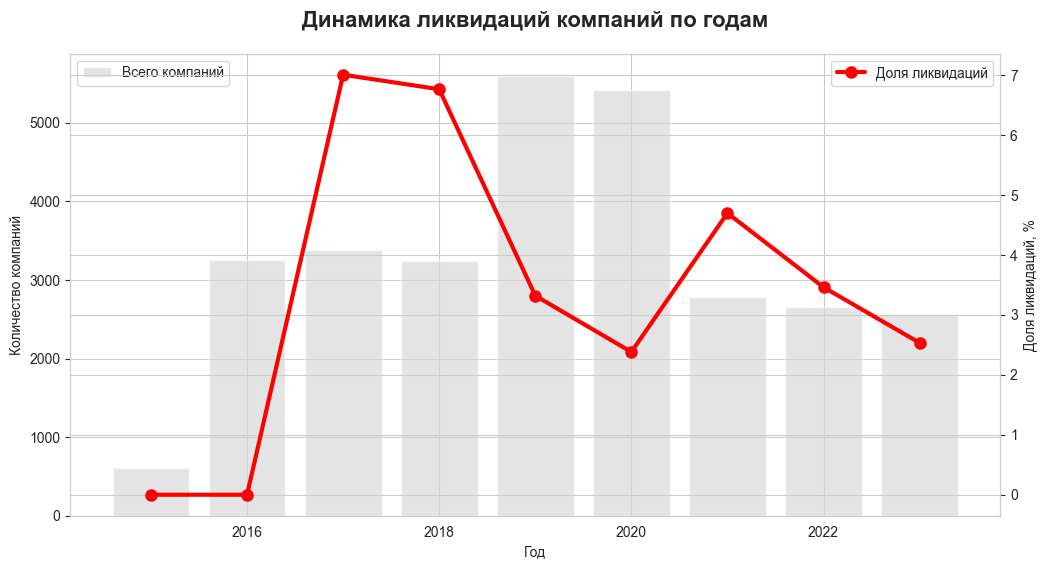

In [15]:
temp = df.groupby('Год')['next_year_liqudation'].agg(['count', 'sum', 'mean'])
temp['Доля, %'] = temp['mean'] * 100

fig, ax1 = plt.subplots(figsize=(12,6))
ax2 = ax1.twinx()

ax1.bar(temp.index, temp['count'], alpha=0.6, color='lightgray', label='Всего компаний')
ax2.plot(temp.index, temp['Доля, %'], color='red', marker='o', linewidth=3, markersize=8, label='Доля ликвидаций')

ax1.set_xlabel('Год')
ax1.set_ylabel('Количество компаний')
ax2.set_ylabel('Доля ликвидаций, %')
ax1.set_title('Динамика ликвидаций компаний по годам', fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

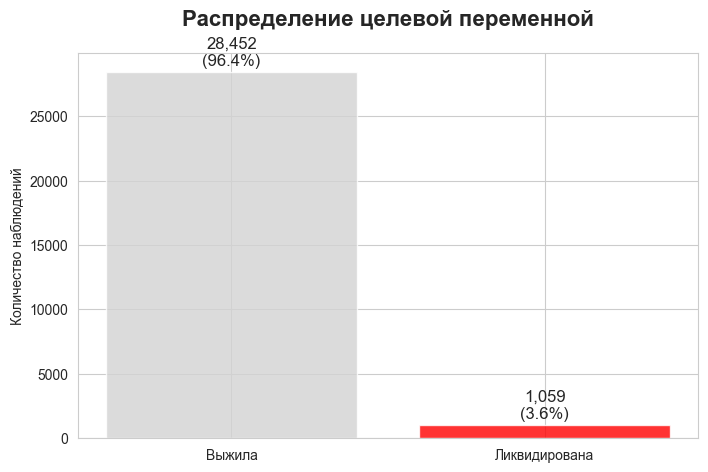

In [16]:
fig, ax = plt.subplots(figsize=(8,5))
bars = plt.bar(['Выжила', 'Ликвидирована'], 
               df['next_year_liqudation'].value_counts().sort_index(),
               color=['lightgray', 'red'], alpha=0.8)

plt.title('Распределение целевой переменной', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Количество наблюдений')
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 500,
             f'{height:,}\n({height/len(df):.1%})', ha='center', fontsize=12)
plt.show()

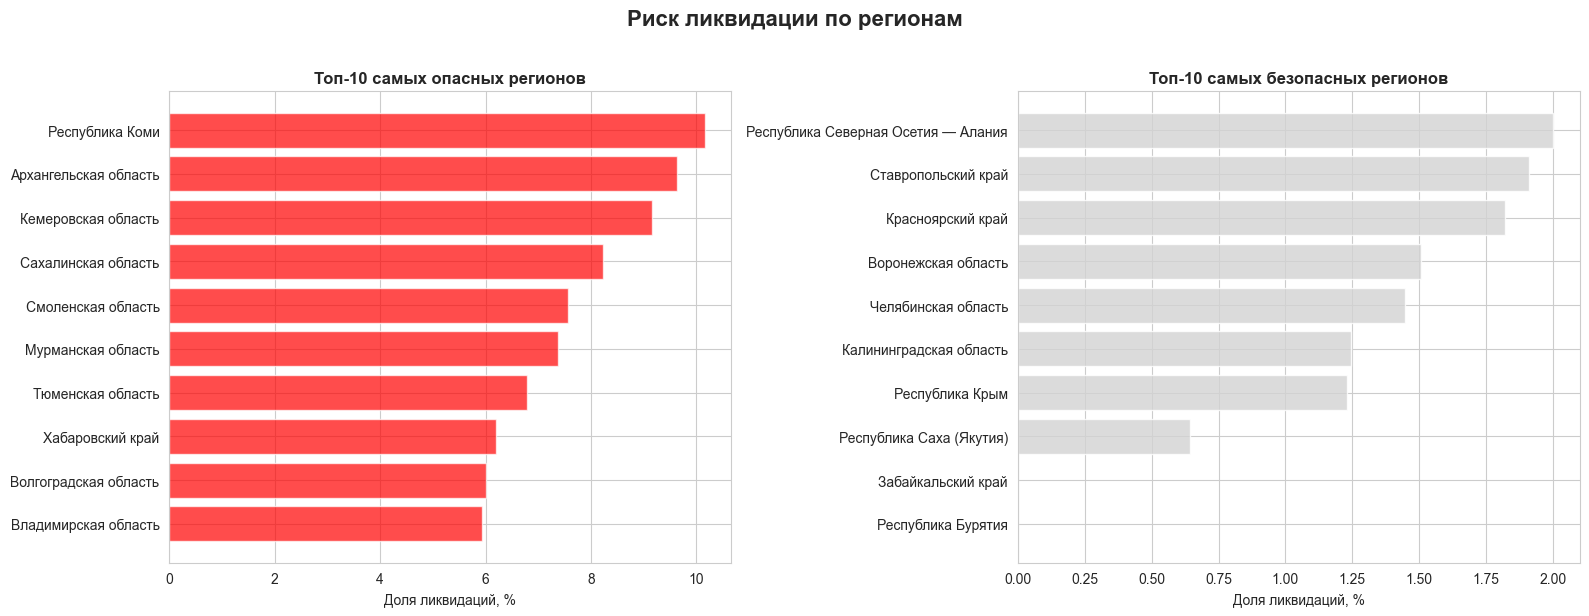

In [17]:
region_risk = df.groupby('Регион')['next_year_liqudation'].agg(['count', 'mean'])
region_risk = region_risk[region_risk['count'] >= 50]
region_risk['Доля, %'] = region_risk['mean'] * 100

top10 = region_risk.sort_values('Доля, %', ascending=False).head(10)
bottom10 = region_risk.sort_values('Доля, %').head(10)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Опасные
ax1.barh(top10.index[::-1], top10['Доля, %'][::-1], color='red', alpha=0.7)
ax1.set_title('Топ-10 самых опасных регионов', fontweight='bold')
ax1.set_xlabel('Доля ликвидаций, %')

# Безопасные
ax2.barh(bottom10.index, bottom10['Доля, %'], color='lightgray', alpha=0.8)
ax2.set_title('Топ-10 самых безопасных регионов', fontweight='bold')
ax2.set_xlabel('Доля ликвидаций, %')

plt.suptitle('Риск ликвидации по регионам', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

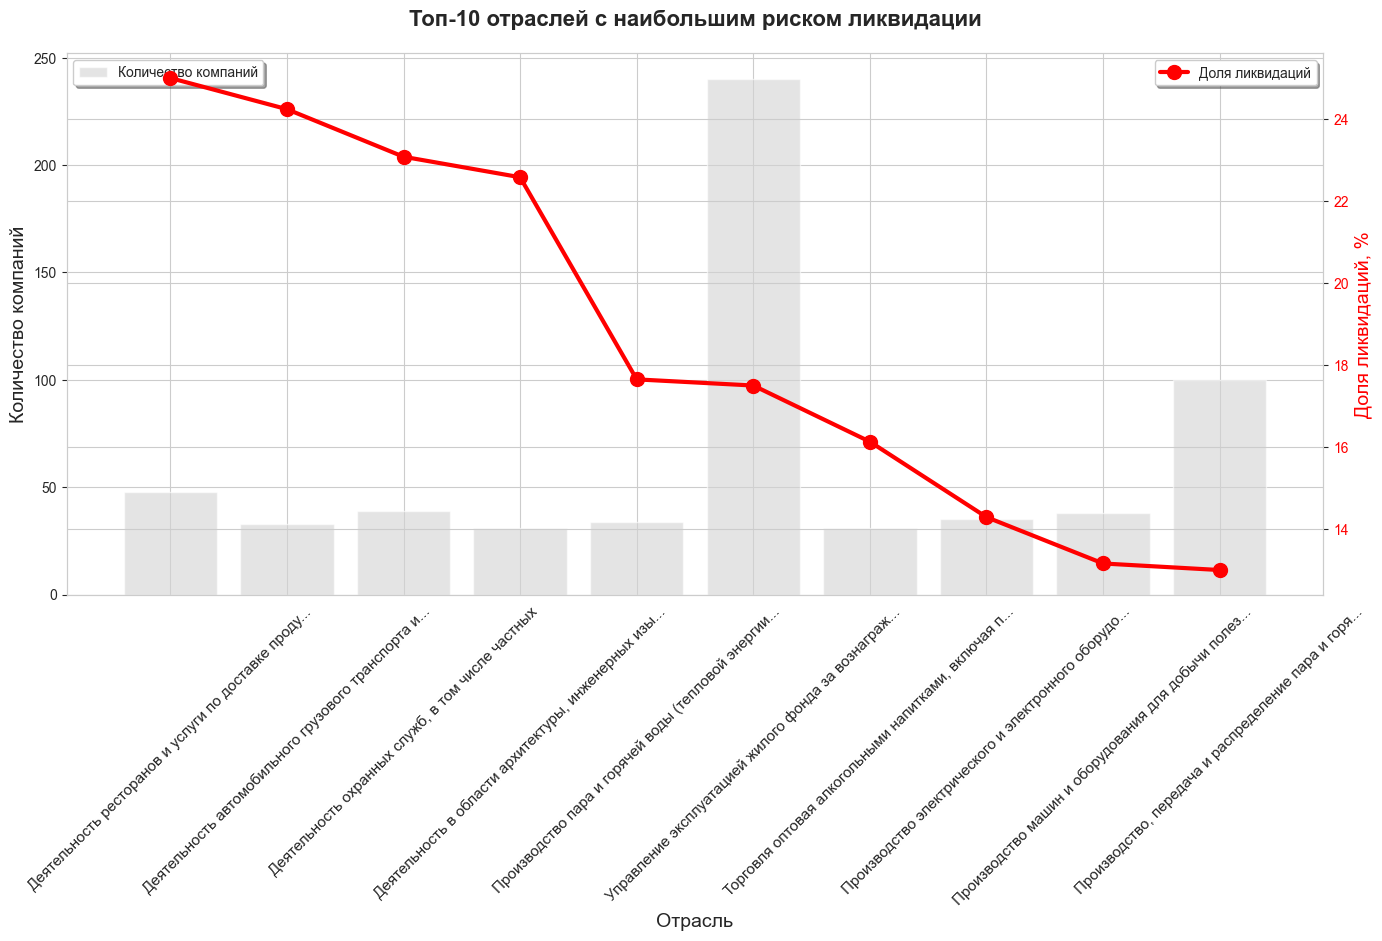

In [20]:
# 5. Топ-10 отраслей по риску ликвидации — ИСПРАВЛЕННАЯ ВЕРСИЯ
industry_risk = df.groupby('Вид деятельности/отрасль')['next_year_liqudation'].agg(['count', 'mean'])
industry_risk = industry_risk[industry_risk['count'] >= 30].copy()
industry_risk['Доля, %'] = (industry_risk['mean'] * 100).round(2)
top_ind = industry_risk.sort_values('Доля, %', ascending=False).head(10)

# Укорачиваем длинные названия (берём первые 50 символов + ...)
top_ind.index = [name[:50] + '...' if len(name) > 50 else name for name in top_ind.index]

fig, ax1 = plt.subplots(figsize=(14, 8))  # увеличил размер
ax2 = ax1.twinx()

# Серые бары — количество компаний
ax1.bar(range(len(top_ind)), top_ind['count'], alpha=0.6, color='lightgray', label='Количество компаний')

# Красная линия с кружками — доля ликвидаций
ax2.plot(range(len(top_ind)), top_ind['Доля, %'], color='red', marker='o', 
         linewidth=3, markersize=10, label='Доля ликвидаций')

# Подписи по оси X — вертикальные, чтобы не налезали
ax1.set_xticks(range(len(top_ind)))
ax1.set_xticklabels(top_ind.index, rotation=45, ha='center', fontsize=11)

ax1.set_xlabel('Отрасль', fontsize=14)
ax1.set_ylabel('Количество компаний', fontsize=14)
ax2.set_ylabel('Доля ликвидаций, %', fontsize=14, color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('Топ-10 отраслей с наибольшим риском ликвидации', 
              fontsize=16, fontweight='bold', pad=20)

# Легенды
ax1.legend(loc='upper left', frameon=True, fancybox=True, shadow=True)
ax2.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)

plt.tight_layout()
plt.subplots_adjust(bottom=0.25)  # добавляем место снизу для подписей
plt.show()

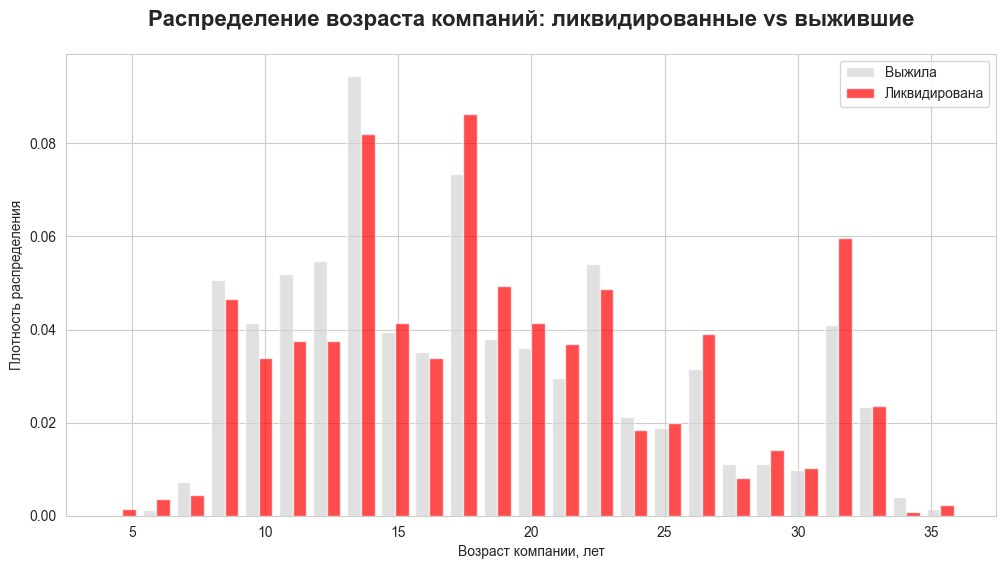

Средний возраст выживших: 18.1 лет
Средний возраст ликвидированных: 18.9 лет


In [27]:
fig, ax = plt.subplots(figsize=(12,6))
plt.hist([df[df['next_year_liqudation']==0]['Возраст компании, лет'],
          df[df['next_year_liqudation']==1]['Возраст компании, лет']],
         bins=25, alpha=0.7, color=['lightgray', 'red'], label=['Выжила', 'Ликвидирована'], density=True)

plt.xlabel('Возраст компании, лет')
plt.ylabel('Плотность распределения')
plt.title('Распределение возраста компаний: ликвидированные vs выжившие', fontsize=16, fontweight='bold', pad=20)
plt.legend()
plt.show()

print(f"Средний возраст выживших: {df[df['next_year_liqudation']==0]['Возраст компании, лет'].mean():.1f} лет")
print(f"Средний возраст ликвидированных: {df[df['next_year_liqudation']==1]['Возраст компании, лет'].mean():.1f} лет")

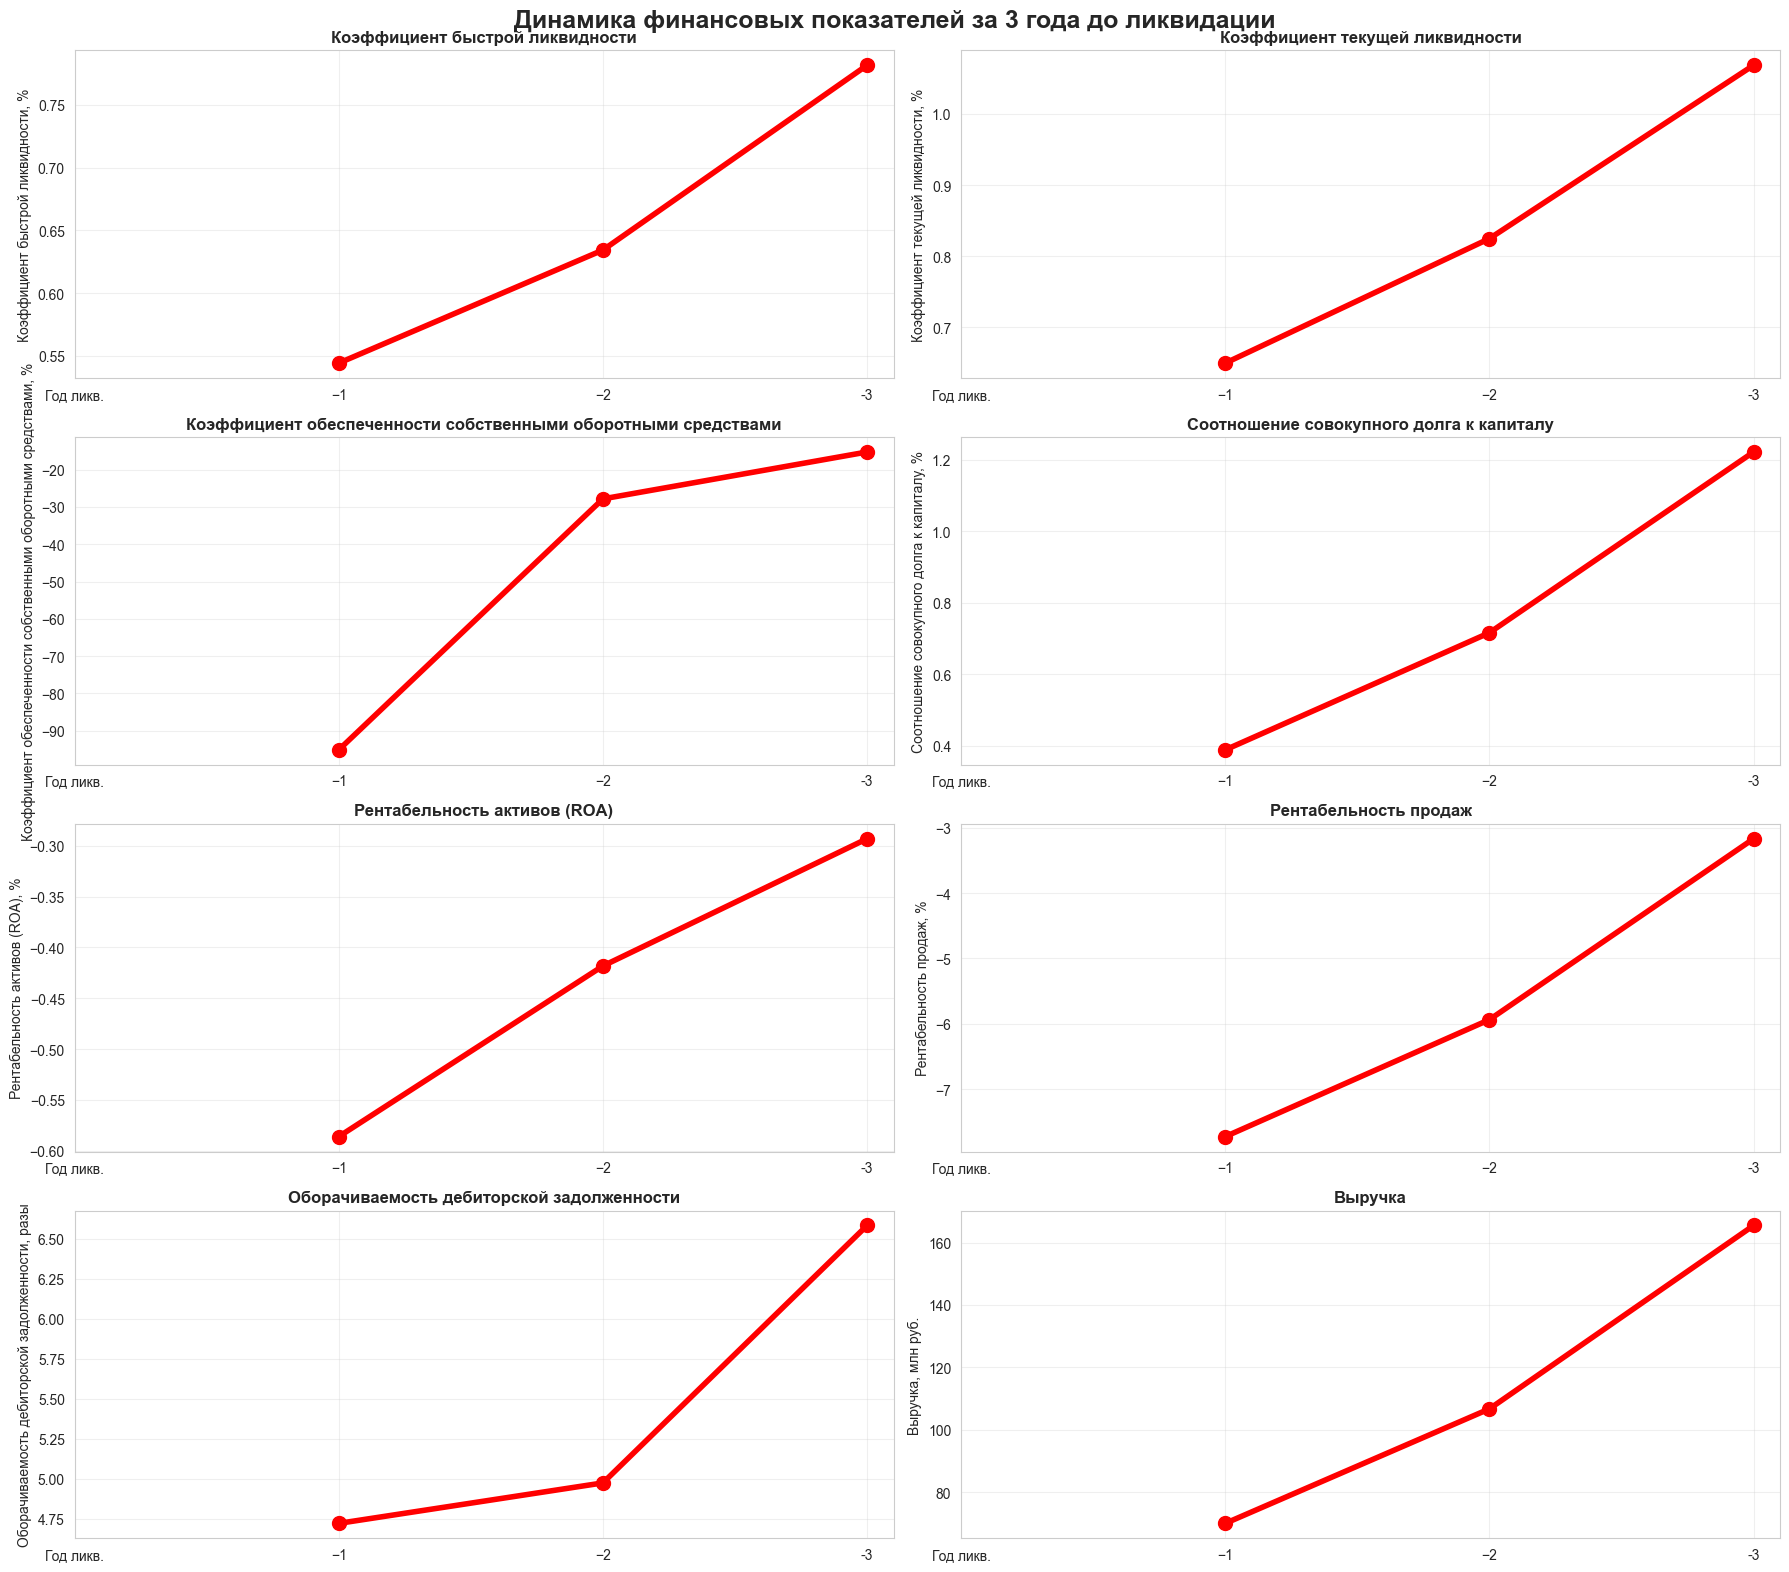

In [29]:
BAR_COLOR = 'lightgray'
LINE_COLOR = 'red'
MARKER_SIZE = 10
LINE_WIDTH = 4

# Подготовка
df['Год_ликвидации'] = df.groupby('Регистрационный номер')['Дата ликвидации'].transform('max')
mask = df['Год_ликвидации'].notna()
df.loc[mask, 'Лет_до_ликвидации'] = df.loc[mask, 'Год_ликвидации'] - df.loc[mask, 'Год']
df_traj = df[df['Лет_до_ликвидации'].between(0, 3)].copy()
df_traj['Лет_до_ликвидации'] = -df_traj['Лет_до_ликвидации'].astype(int)

coefs = [
    'Коэффициент быстрой ликвидности, %',
    'Коэффициент текущей ликвидности, %',
    'Коэффициент обеспеченности собственными оборотными средствами, %',
    'Соотношение совокупного долга к капиталу, %',
    'Рентабельность активов (ROA), %',
    'Рентабельность продаж, %',
    'Оборачиваемость дебиторской задолженности, разы',
    'Выручка, RUB'
]

fig, axes = plt.subplots(4, 2, figsize=(18, 16))
axes = axes.flatten()

for i, coef in enumerate(coefs):
    traj = df_traj.groupby('Лет_до_ликвидации')[coef].mean()
    if 'Выручка' in coef:
        traj = traj / 1_000_000
        ylabel = 'Выручка, млн руб.'
    else:
        ylabel = coef
    
    axes[i].plot(traj.index, traj.values, color=LINE_COLOR, marker='o', 
                 linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
    axes[i].set_xticks([-3,-2,-1,0])
    axes[i].set_xticklabels(['-3','−2','−1','Год ликв.'])
    axes[i].set_title(coef.split(',')[0], fontweight='bold')
    axes[i].set_ylabel(ylabel)
    axes[i].invert_xaxis()
    axes[i].grid(alpha=0.3)

plt.suptitle('Динамика финансовых показателей за 3 года до ликвидации', 
             fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout(); plt.show()

In [25]:
print(df.columns.tolist())

['Год', 'Регистрационный номер', 'Возраст компании, лет', 'Дата ликвидации', 'Вид деятельности/отрасль', 'Форма собственности', 'Важная информация', 'Выручка, RUB', 'Коэффициент быстрой ликвидности, %', 'Коэффициент обеспеченности собственными оборотными средствами, %', 'Коэффициент оборачиваемости совокупных активов, %', 'Коэффициент текущей ликвидности, %', 'Оборачиваемость дебиторской задолженности, разы', 'Оборачиваемость кредиторской задолженности, разы', 'Рентабельность активов (ROA), %', 'Рентабельность капитала (ROE), %', 'Рентабельность продаж, %', 'Соотношение совокупного долга к капиталу, %', 'next_year_liqudation', 'ogrn_str', 'region_code', 'Регион', 'ВРП_на_душу', 'USD_RUB_средневзвешенный', 'Индекс_предпринимательской_уверенности', 'Ключевая_ставка_средняя', 'МРОТ_на_конец_года', 'Год_ликвидации', 'Лет_до_ликвидации']


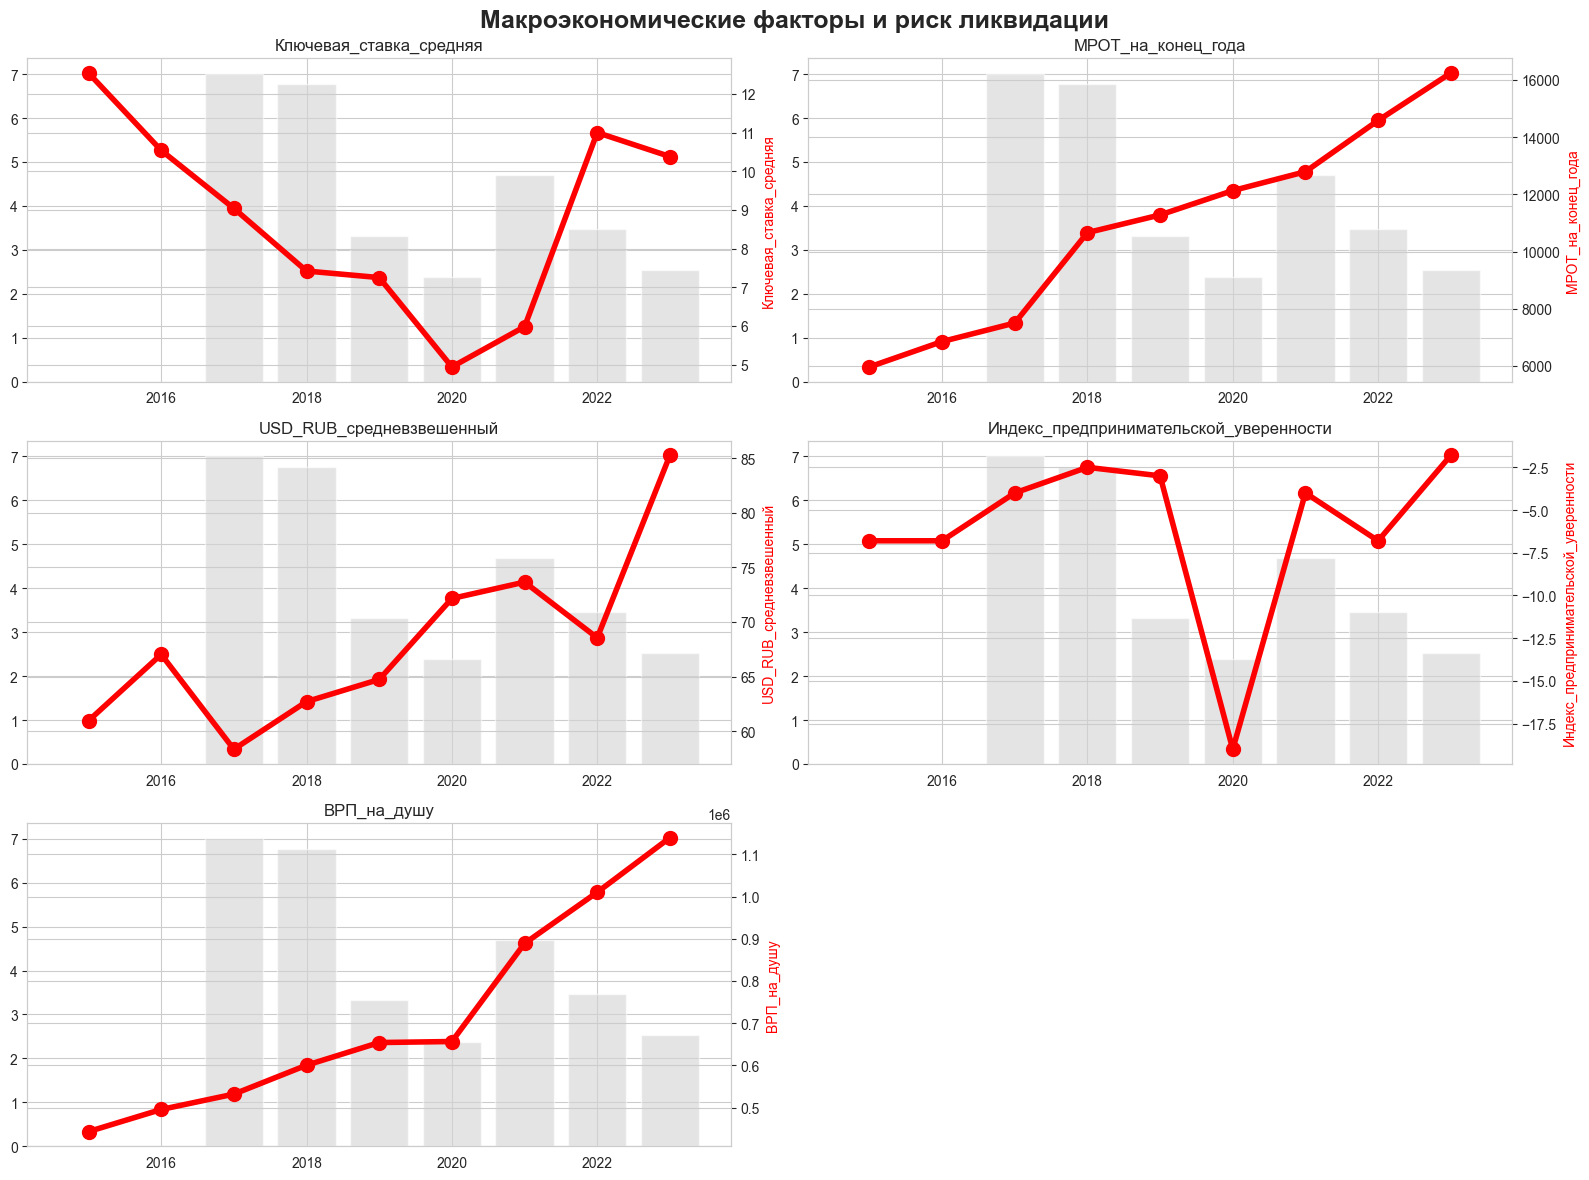

In [30]:
macro = ['Ключевая_ставка_средняя', 'МРОТ_на_конец_года', 'USD_RUB_средневзвешенный', 
         'Индекс_предпринимательской_уверенности', 'ВРП_на_душу']

temp = df.groupby('Год')[macro + ['next_year_liqudation']].mean()
temp['Доля ликвидаций, %'] = temp['next_year_liqudation']*100

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(macro + ['Доля ликвидаций, %']):
    if i == 5:
        axes[i].axis('off'); continue
    ax2 = axes[i].twinx()
    axes[i].bar(temp.index, temp['Доля ликвидаций, %'], alpha=0.6, color=BAR_COLOR)
    ax2.plot(temp.index, temp[col], color=LINE_COLOR, marker='o', linewidth=LINE_WIDTH, markersize=MARKER_SIZE)
    axes[i].set_title(col)
    ax2.set_ylabel(col, color='red')

plt.suptitle('Макроэкономические факторы и риск ликвидации', fontweight='bold', fontsize=18)
plt.tight_layout(); plt.show()

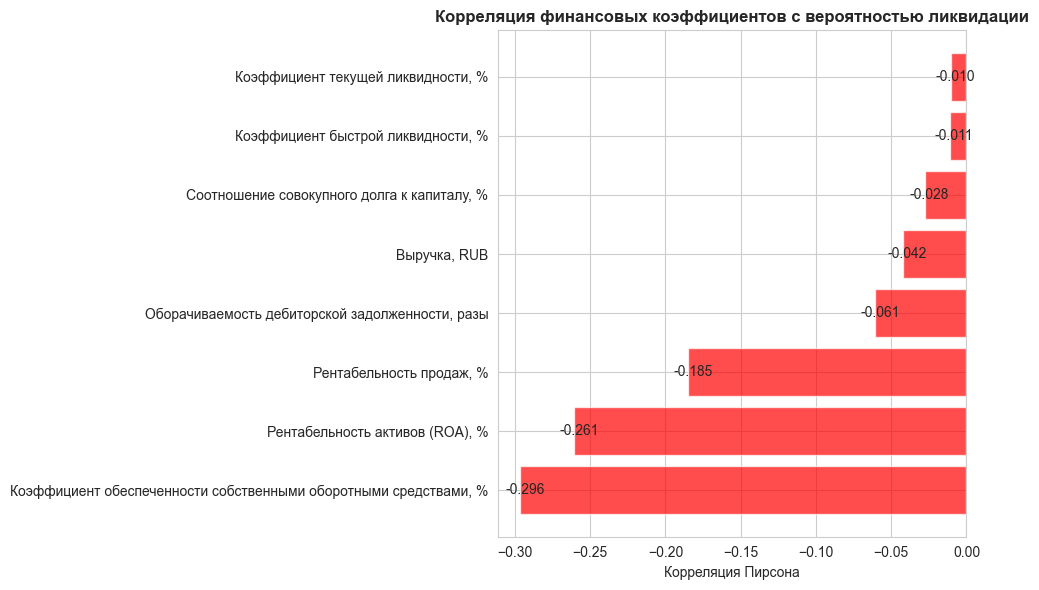

In [31]:
fin_cols = ['Коэффициент быстрой ликвидности, %','Коэффициент текущей ликвидности, %',
            'Коэффициент обеспеченности собственными оборотными средствами, %','Рентабельность активов (ROA), %',
            'Рентабельность продаж, %','Соотношение совокупного долга к капиталу, %',
            'Оборачиваемость дебиторской задолженности, разы','Выручка, RUB']

corr = df[fin_cols + ['next_year_liqudation']].corr()['next_year_liqudation'].drop('next_year_liqudation')
corr = corr.sort_values()

plt.figure(figsize=(10,6))
plt.barh(corr.index, corr.values, color='red', alpha=0.7)
plt.title('Корреляция финансовых коэффициентов с вероятностью ликвидации', fontweight='bold')
plt.xlabel('Корреляция Пирсона')
for i, v in enumerate(corr.values):
    plt.text(v + (0.01 if v>0 else -0.01), i, f'{v:.3f}', va='center')
plt.tight_layout(); plt.show()

После очистки: 28,798 наблюдений


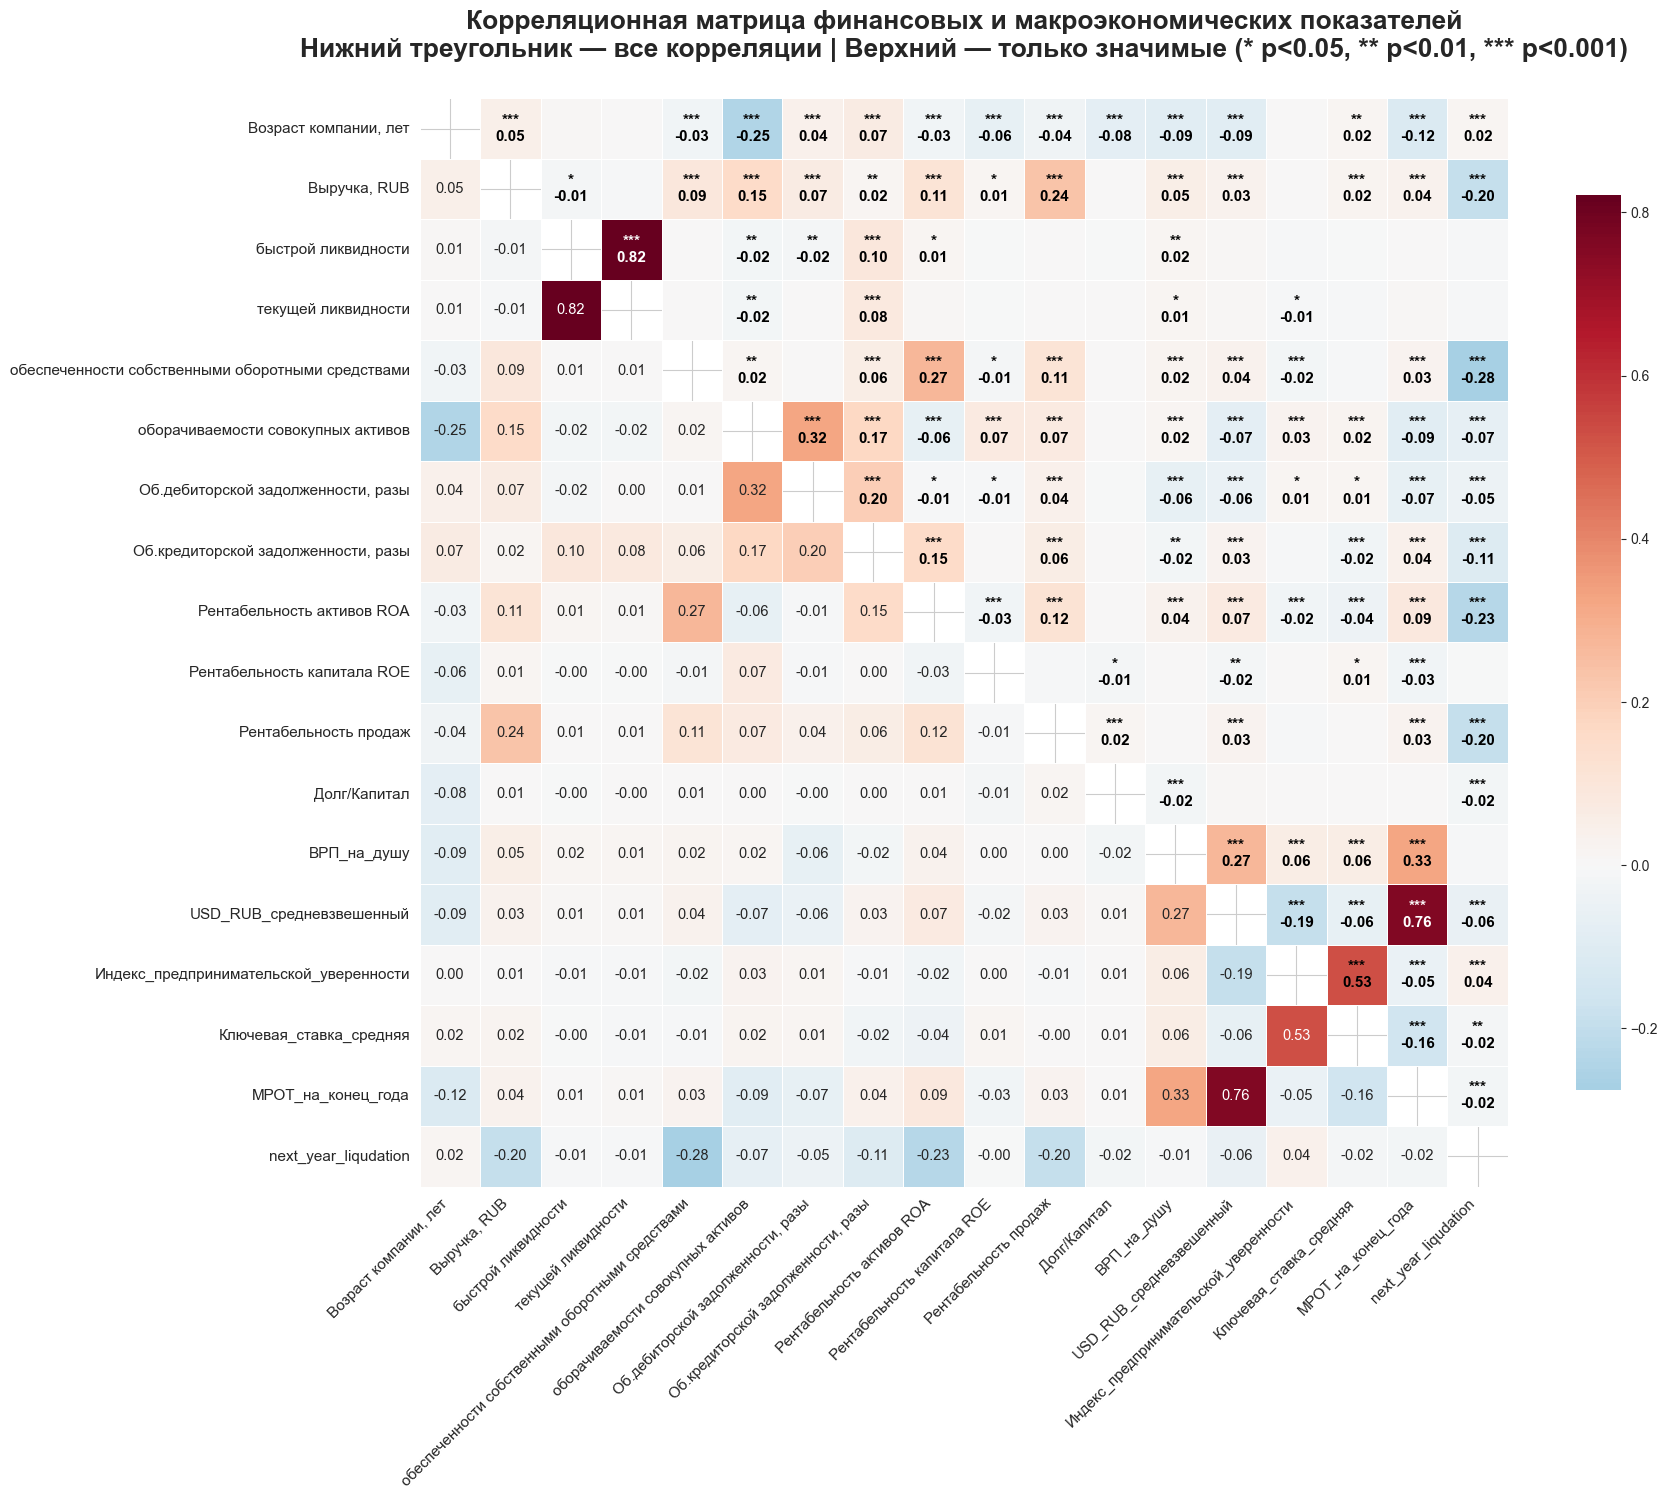

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# === 1. Выборка и очистка ===
cols = [
    'Возраст компании, лет',
    'Выручка, RUB',
    'Коэффициент быстрой ликвидности, %',
    'Коэффициент текущей ликвидности, %',
    'Коэффициент обеспеченности собственными оборотными средствами, %',
    'Коэффициент оборачиваемости совокупных активов, %',
    'Оборачиваемость дебиторской задолженности, разы',
    'Оборачиваемость кредиторской задолженности, разы',
    'Рентабельность активов (ROA), %',
    'Рентабельность капитала (ROE), %',
    'Рентабельность продаж, %',
    'Соотношение совокупного долга к капиталу, %',
    'ВРП_на_душу',
    'USD_RUB_средневзвешенный',
    'Индекс_предпринимательской_уверенности',
    'Ключевая_ставка_средняя',
    'МРОТ_на_конец_года',
    'next_year_liqudation'
]

data = df[cols].copy()
data = data.replace([np.inf, -np.inf], np.nan)
data['Выручка, RUB'] = np.log1p(data['Выручка, RUB'])
data = data.dropna()
print(f"После очистки: {len(data):,} наблюдений")

# === 2. Безопасный расчёт корреляции + p-value ===
def pearsonr_safe(x, y):
    x, y = np.asarray(x), np.asarray(y)
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) < 2:
        return np.nan, 1.0
    return stats.pearsonr(x, y)

n = len(cols)
corr_matrix = np.zeros((n, n))
p_matrix = np.ones((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            corr_matrix[i, j] = 1.0
            continue
        r, p = pearsonr_safe(data.iloc[:, i], data.iloc[:, j])
        corr_matrix[i, j] = np.round(r, 3) if not np.isnan(r) else 0
        p_matrix[i, j] = p if not np.isnan(p) else 1.0

corr_df = pd.DataFrame(corr_matrix, index=cols, columns=cols)

# === 3. Звёздочки ===
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

# === 4. РИСУЕМ ХИТМАП ПРАВИЛЬНО ===
fig, ax = plt.subplots(figsize=(18, 15))

# Нижний треугольник — все значения
mask_lower = np.triu(np.ones_like(corr_df, dtype=bool))   # True выше главной диагонали
sns.heatmap(corr_df, mask=mask_lower, cmap="RdBu_r", center=0,
            annot=True, fmt=".2f", square=True, linewidths=.7,
            cbar_kws={"shrink": .8}, ax=ax, annot_kws={"size": 10.5})

# Верхний треугольник — только значимые
mask_upper = np.tril(np.ones_like(corr_df, dtype=bool))   # True ниже главной диагонали
sns.heatmap(corr_df, mask=mask_upper, cmap="RdBu_r", center=0,
            annot=False, square=True, linewidths=.7, ax=ax, cbar=False)

# Ручное нанесение значимых корреляций в верхний треугольник
for i in range(n):
    for j in range(n):
        if i < j:  # только верхний треугольник
            r = corr_df.iloc[i, j]
            p = p_matrix[i, j]
            if p < 0.05:  # только значимые
                text = f"{stars(p)}\n{r:.2f}"
                color = 'white' if abs(r) > 0.6 else 'black'
                ax.text(j + 0.5, i + 0.5, text,
                        ha='center', va='center',
                        fontsize=11, fontweight='bold', color=color)

# Подписи
short_labels = [c.replace(', %','').replace(' (ROA)',' ROA').replace(' (ROE)',' ROE')
                    .replace('Коэффициент ','')
                    .replace('Соотношение совокупного долга к капиталу','Долг/Капитал')
                    .replace('Оборачиваемость ','Об.')
                for c in cols]

ax.set_xticklabels(short_labels, rotation=45, ha='right', fontsize=11)
ax.set_yticklabels(short_labels, rotation=0, fontsize=11)

plt.title('Корреляционная матрица финансовых и макроэкономических показателей\n'
          'Нижний треугольник — все корреляции | Верхний — только значимые (* p<0.05, ** p<0.01, *** p<0.001)',
          fontsize=19, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

In [33]:
print(df.columns.tolist())

['Год', 'Регистрационный номер', 'Возраст компании, лет', 'Дата ликвидации', 'Вид деятельности/отрасль', 'Форма собственности', 'Важная информация', 'Выручка, RUB', 'Коэффициент быстрой ликвидности, %', 'Коэффициент обеспеченности собственными оборотными средствами, %', 'Коэффициент оборачиваемости совокупных активов, %', 'Коэффициент текущей ликвидности, %', 'Оборачиваемость дебиторской задолженности, разы', 'Оборачиваемость кредиторской задолженности, разы', 'Рентабельность активов (ROA), %', 'Рентабельность капитала (ROE), %', 'Рентабельность продаж, %', 'Соотношение совокупного долга к капиталу, %', 'next_year_liqudation', 'ogrn_str', 'region_code', 'Регион', 'ВРП_на_душу', 'USD_RUB_средневзвешенный', 'Индекс_предпринимательской_уверенности', 'Ключевая_ставка_средняя', 'МРОТ_на_конец_года', 'Год_ликвидации', 'Лет_до_ликвидации']


После очистки: 28,798 наблюдений
Проверка: среднее within-значение по компаниям должно быть ≈0
                       Ключевая_ставка_средняя  USD_RUB_средневзвешенный
Регистрационный номер                                                   
1.001602e+12                               0.0                      -0.0
1.020101e+12                              -0.0                      -0.0
1.020101e+12                               0.0                      -0.0
1.020101e+12                              -0.0                      -0.0
1.020201e+12                               0.0                      -0.0


c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


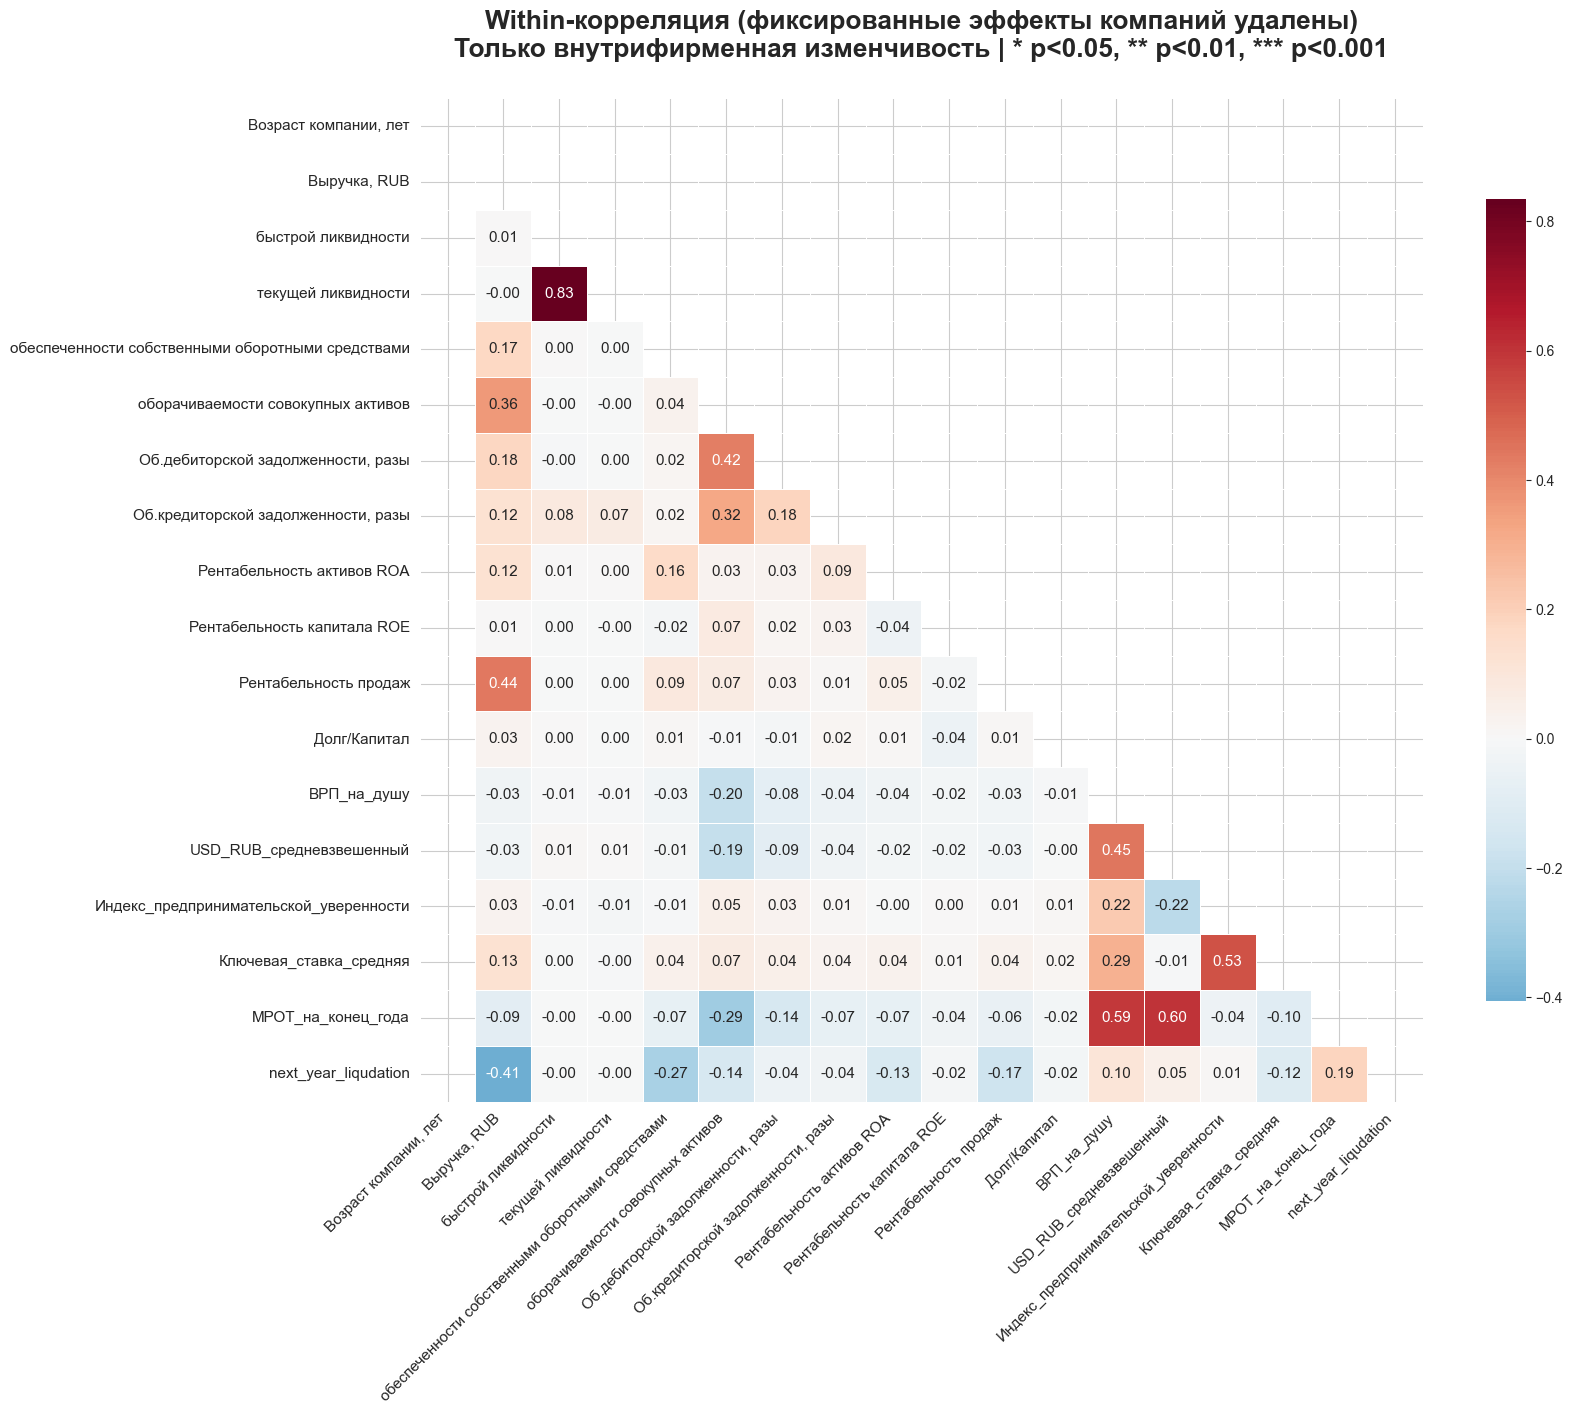

In [39]:
# ------------------------------------------------------------
# 1. Выбираем количественные переменные
# ------------------------------------------------------------
quant_cols = [
    'Возраст компании, лет',
    'Выручка, RUB',
    'Коэффициент быстрой ликвидности, %',
    'Коэффициент текущей ликвидности, %',
    'Коэффициент обеспеченности собственными оборотными средствами, %',
    'Коэффициент оборачиваемости совокупных активов, %',
    'Оборачиваемость дебиторской задолженности, разы',
    'Оборачиваемость кредиторской задолженности, разы',
    'Рентабельность активов (ROA), %',
    'Рентабельность капитала (ROE), %',
    'Рентабельность продаж, %',
    'Соотношение совокупного долга к капиталу, %',
    'ВРП_на_душу',
    'USD_RUB_средневзвешенный',
    'Индекс_предпринимательской_уверенности',
    'Ключевая_ставка_средняя',
    'МРОТ_на_конец_года',
    'next_year_liqudation'
]

data = df[quant_cols + ['Регистрационный номер', 'Год']].copy()

# ------------------------------------------------------------
# 2. Очистка (обязательно!)
# ------------------------------------------------------------
data = data.replace([np.inf, -np.inf], np.nan)
data['Выручка, RUB'] = np.log1p(data['Выручка, RUB'])   # логарифм
data = data.dropna(subset=quant_cols)                  # удаляем строки с NaN в признаках

print(f"После очистки: {len(data):,} наблюдений")

# ------------------------------------------------------------
# 3. Within-трансформация (деминирование по компании)
#    x_it^within = x_it − x̄_i
# ------------------------------------------------------------
# === КЛЮЧЕВОЙ МОМЕНТ: деминируем ВСЁ, включая макро! ===
data_within = data.copy()

for col in quant_cols:   # ← ВОТ ТУТ ВСЁ, включая ставку, курс и т.д.
    company_mean = data.groupby('Регистрационный номер')[col].transform('mean')
    data_within[col] = data[col] - company_mean

# Проверим, что макро теперь "обезличены"
print("Проверка: среднее within-значение по компаниям должно быть ≈0")
print(data_within.groupby('Регистрационный номер')[['Ключевая_ставка_средняя', 
                                                  'USD_RUB_средневзвешенный']].mean().round(2).head())
# Должны быть очень близки к нулю
for col in quant_cols:
    # Считаем среднее по компании за всё время
    company_mean = data.groupby('Регистрационный номер')[col].transform('mean')
    # Вычитаем индивидуальное среднее
    data_within[col] = data[col] - company_mean

# Теперь все фиксированные эффекты компаний удалены

# ------------------------------------------------------------
# 4. Корреляция на within-данных
# ------------------------------------------------------------
corr_within = data_within[quant_cols].corr().round(3)

# ------------------------------------------------------------
# 5. p-value на within-данных (тоже корректно!)
# ------------------------------------------------------------
n = len(quant_cols)
p_within = pd.DataFrame(np.ones((n, n)), index=quant_cols, columns=quant_cols)

for i, col1 in enumerate(quant_cols):
    for j, col2 in enumerate(quant_cols):
        if i >= j: 
            continue
        x = data_within[col1].dropna()
        y = data_within[col2].dropna()
        if len(x) > 10:  # минимум наблюдений
            _, p = stats.pearsonr(x, y)
            p_within.loc[col1, col2] = p
            p_within.loc[col2, col1] = p

# ------------------------------------------------------------
# 6. Красивый хитмап с звёздочками (within-корреляция)
# ------------------------------------------------------------
plt.figure(figsize=(17, 14))

mask = np.triu(np.ones_like(corr_within, dtype=bool))

sns.heatmap(corr_within,
            mask=mask,
            cmap="RdBu_r",
            center=0,
            annot=True,
            fmt=".2f",
            square=True,
            linewidths=.7,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 11})

# Звёздочки значимости
def stars(p):
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return ""

for i in range(n):
    for j in range(i+1, n):
        if not mask[i, j]:
            p = p_within.iloc[i, j]
            if p < 0.05:
                r = corr_within.iloc[i, j]
                color = 'white' if abs(r) > 0.6 else 'black'
                plt.text(j+0.5, i+0.7, stars(p),
                         ha='center', va='center', fontsize=16,
                         fontweight='bold', color=color)

# Короткие подписи
short_labels = [c.replace(', %','').replace(' (ROA)',' ROA').replace(' (ROE)',' ROE')
                    .replace('Коэффициент ','').replace('Соотношение совокупного долга к капиталу','Долг/Капитал')
                    .replace('Оборачиваемость ','Об.')
                for c in quant_cols]

plt.xticks(ticks=np.arange(n)+0.5, labels=short_labels, rotation=45, ha='right', fontsize=11)
plt.yticks(ticks=np.arange(n)+0.5, labels=short_labels, rotation=0, fontsize=11)

plt.title('Within-корреляция (фиксированные эффекты компаний удалены)\n'
          'Только внутрифирменная изменчивость | * p<0.05, ** p<0.01, *** p<0.001',
          fontsize=19, fontweight='bold', pad=30)

plt.tight_layout()
plt.show()

Учитывая панельную структуру данных, стандартная корреляция Пирсона приводит к существенному завышению значимости. Для устранения фиксированных эффектов компаний проведена within-трансформация (деминирование по среднему значению каждой компании). Полученные within-корреляции отражают только внутрифирменную изменчивость и являются несмещённой оценкой взаимосвязей.

In [41]:
from lifelines import KaplanMeierFitter

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 13
sns.set_style("whitegrid")

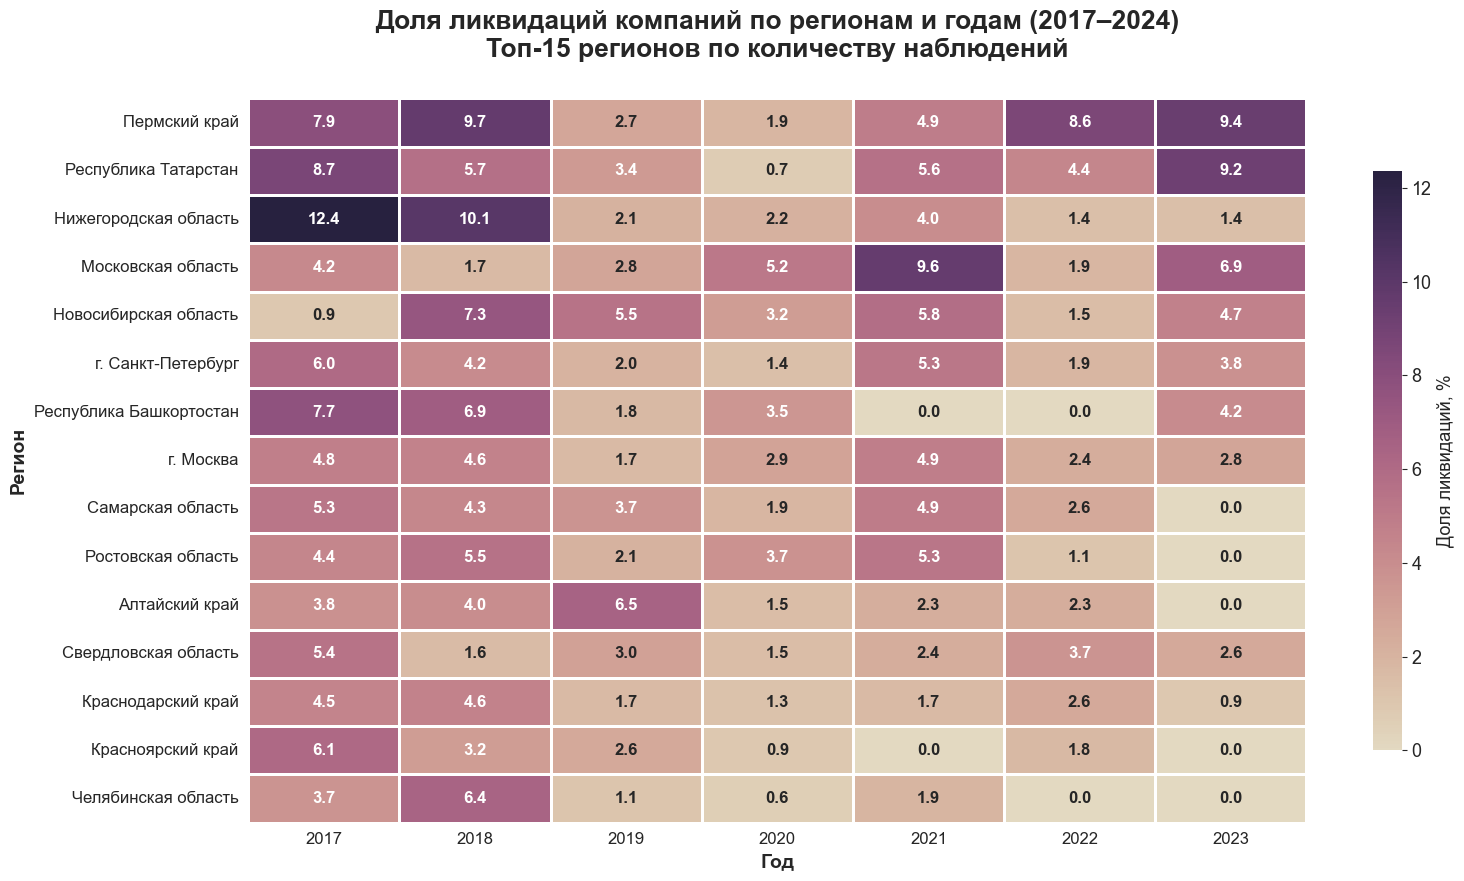

Самые опасные комбинации год + регион (2017–2024):
Регион                 Год 
Нижегородская область  2017    12.4
                       2018    10.1
Пермский край          2018     9.7
Московская область     2021     9.6
Пермский край          2023     9.4
Республика Татарстан   2023     9.2
                       2017     8.7
Пермский край          2022     8.6
dtype: float64


In [43]:
# ────────────────────── ТЕПЛОВАЯ КАРТА ДОЛЯ ЛИКВИДАЦИЙ ПО ГОДАМ И РЕГИОНАМ ──────────────────────
top_regions = df['Регион'].value_counts().head(15).index
heat_data = df[df['Регион'].isin(top_regions)]

# УБИРАЕМ 2015 и 2016 годы
heat_data = heat_data[~heat_data['Год'].isin([2015, 2016])]

pivot = heat_data.pivot_table(
    values='next_year_liqudation',
    index='Регион',
    columns='Год',
    aggfunc='mean'
) * 100

# Сортируем регионы по среднему риску за весь период (от опасного к безопасному)
pivot = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

plt.figure(figsize=(16, 9))

# Красивая палитра: от бежевого до тёмно-бордового
cmap = sns.color_palette("ch:s=-.2,r=.6", as_cmap=True)   # или: "YlOrBr", "Reds", "BuPu"

sns.heatmap(pivot, 
            annot=True, 
            fmt=".1f", 
            cmap=cmap,
            linewidths=0.8,
            linecolor='white',
            cbar_kws={'label': 'Доля ликвидаций, %', 'shrink': 0.8},
            annot_kws={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Доля ликвидаций компаний по регионам и годам (2017–2024)\nТоп-15 регионов по количеству наблюдений', 
          fontsize=19, fontweight='bold', pad=30)

plt.xlabel('Год', fontsize=14, fontweight='bold')
plt.ylabel('Регион', fontsize=14, fontweight='bold')

plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

# Дополнительно: топ-5 самых опасных комбинаций
print("Самые опасные комбинации год + регион (2017–2024):")
print(pivot.stack().sort_values(ascending=False).head(8).round(1))

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_16812\856877730.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for label, group in km_data.groupby(ages_groups):


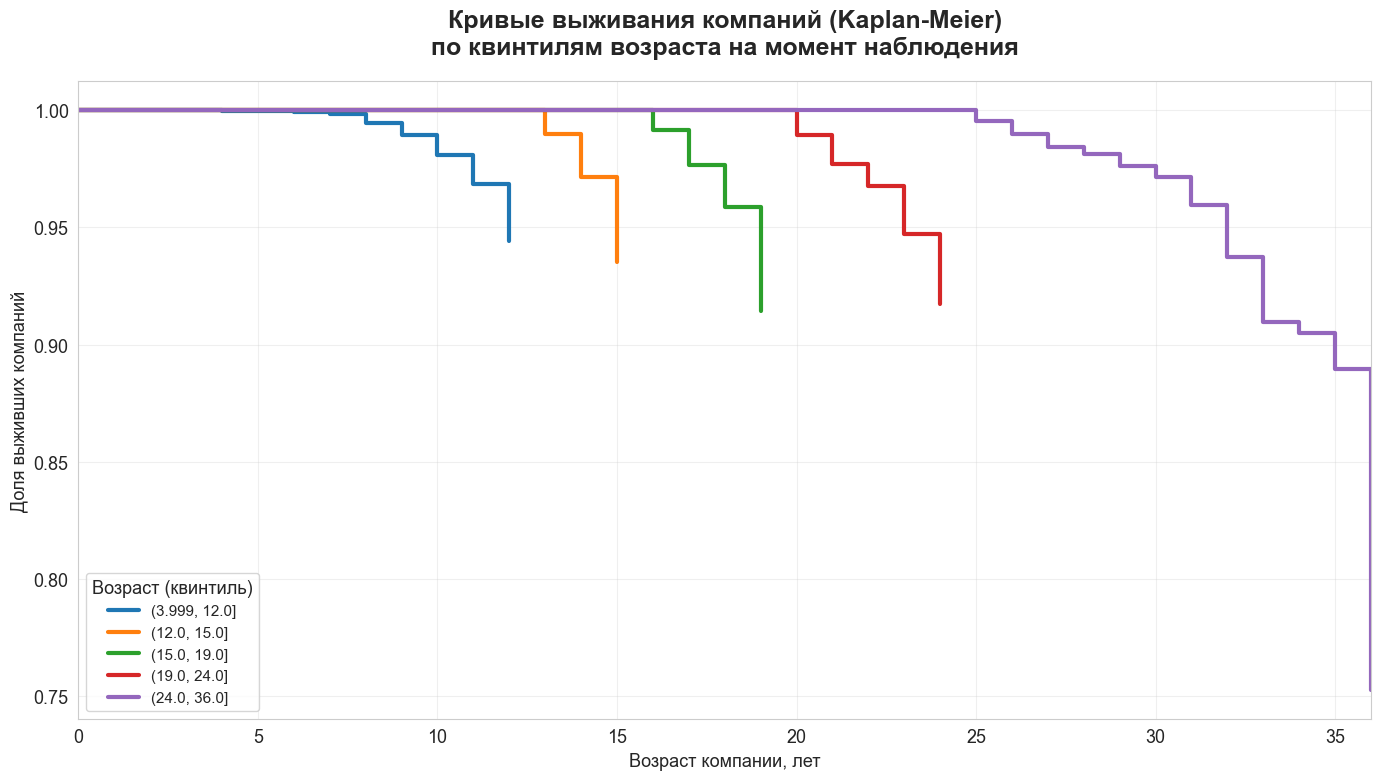

Чем моложе компания — тем выше риск ликвидации в ближайший год


In [44]:
# Подготовка: возраст на момент наблюдения и факт ликвидации на следующий год
km_data = df[['Возраст компании, лет', 'next_year_liqudation']].copy()
km_data = km_data.dropna()

# Округляем возраст до целых лет
km_data['age'] = km_data['Возраст компании, лет'].astype(int)
km_data['event'] = km_data['next_year_liqudation']

# Kaplan-Meier
kmf = KaplanMeierFitter()

plt.figure(figsize=(14, 8))
ages_groups = pd.qcut(km_data['age'], q=5, duplicates='drop')  # делим на квинтили

for label, group in km_data.groupby(ages_groups):
    kmf.fit(durations=group['age'], event_observed=group['event'], label=f'{label}')
    kmf.plot_survival_function(ci_show=False, linewidth=3)

plt.title('Кривые выживания компаний (Kaplan-Meier)\nпо квинтилям возраста на момент наблюдения', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Возраст компании, лет')
plt.ylabel('Доля выживших компаний')
plt.xlim(0, km_data['age'].max())
plt.legend(title='Возраст (квинтиль)', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Вывод:
print("Чем моложе компания — тем выше риск ликвидации в ближайший год")

C:\Users\Пользователь\AppData\Local\Temp\ipykernel_16812\817097017.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Выжила', 'Ликвидирована'], fontsize=14)


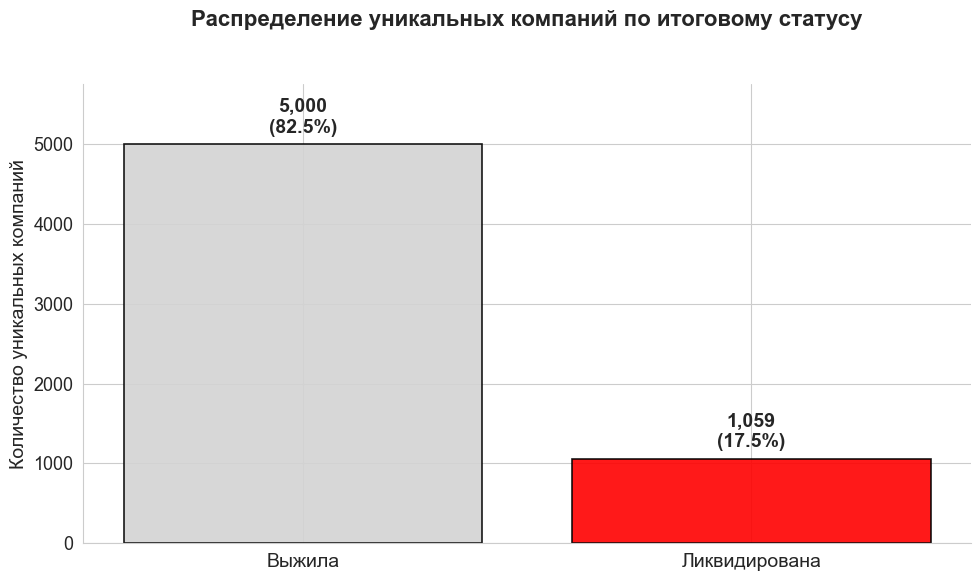

Всего уникальных компаний: 6,059
Выжили за весь период: 5,000 (82.5%)
Ликвидированы хотя бы раз: 1,059 (17.5%)


In [47]:
# ────────────────────── РАСПРЕДЕЛЕНИЕ УНИКАЛЬНЫХ КОМПАНИЙ ПО СТАТУСУ ──────────────────────
# 1. Определяем статус компании за весь период
company_status = (
    df.groupby('Регистрационный номер')['next_year_liqudation']
      .max()  # если хоть раз было 1 → компания ликвидировалась
      .map({0: 'Выжила', 1: 'Ликвидирована'})
      .value_counts()
      .reindex(['Выжила', 'Ликвидирована'])  # порядок как надо
)

# 2. Строим график
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(company_status.index, 
              company_status.values,
              color=['lightgray', 'red'], 
              alpha=0.9, 
              edgecolor='black', 
              linewidth=1.2)

ax.set_title('Распределение уникальных компаний по итоговому статусу\n', 
             fontsize=16, fontweight='bold', pad=25)

ax.set_ylabel('Количество уникальных компаний', fontsize=14)
ax.set_ylim(0, company_status.max() * 1.15)

# Подписи с количеством и процентом
total_companies = company_status.sum()
for i, (label, count) in enumerate(company_status.items()):
    ax.text(i, count + total_companies*0.015, 
            f'{count:,}\n({count/total_companies:.1%})', 
            ha='center', va='bottom', fontsize=14, fontweight='bold')

# Убираем лишние подписи на осях
ax.set_xticklabels(['Выжила', 'Ликвидирована'], fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Дополнительно — выводим точные цифры
print(f"Всего уникальных компаний: {total_companies:,}")
print(f"Выжили за весь период: {company_status['Выжила']:,} ({company_status['Выжила']/total_companies:.1%})")
print(f"Ликвидированы хотя бы раз: {company_status['Ликвидирована']:,} ({company_status['Ликвидирована']/total_companies:.1%})")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ────────────────────── 1. Выборка признаков ──────────────────────
features = [
    'Возраст компании, лет',
    'Выручка, RUB',
    'Коэффициент быстрой ликвидности, %',
    'Коэффициент текущей ликвидности, %',
    'Коэффициент обеспеченности собственными оборотными средствами, %',
    'Соотношение совокупного долга к капиталу, %',
    'Рентабельность активов (ROA), %',
    'Рентабельность продаж, %',
    'Ключевая_ставка_средняя',
    'USD_RUB_средневзвешенный',
    'ВРП_на_душу'
]

target = 'next_year_liqudation'

data = df[features + [target, 'Год', 'Регистрационный номер']].copy()

# ────────────────────── 2. Очистка и преобразования ──────────────────────
data = data.replace([np.inf, -np.inf], np.nan)
data['Выручка, RUB'] = np.log1p(data['Выручка, RUB'])
data = data.dropna()

print(f"Полная выборка: {len(data):,} наблюдений, годы: {sorted(data['Год'].unique())}")

# ────────────────────── 3. ЧЕСТНЫЙ ВРЕМЕННОЙ SPLIT ──────────────────────
# Тренируем на старых годах → тестируем на новых (как в реальности!)
train_years = [2017, 2018, 2019, 2020, 2021]   # ← можно менять
test_years  = [2022, 2023, 2024]

train = data[data['Год'].isin(train_years)].copy()
test  = data[data['Год'].isin(test_years)].copy()

print(f"\nTrain: {len(train):,} наблюдений ({train['Год'].min()}–{train['Год'].max()})")
print(f"Test:  {len(test):,} наблюдений ({test['Год'].min()}–{test['Год'].max()})")
print(f"Доля ликвидаций в train: {train[target].mean():.2%}")
print(f"Доля ликвидаций в test:  {test[target].mean():.2%}")

X_train = train[features]
y_train = train[target]
X_test  = test[features]
y_test  = test[target]

# ────────────────────── 4. Стандартизация (только по train!) ──────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=features, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),  columns=features, index=X_test.index)

# ────────────────────── 5. Простой логит ──────────────────────
logit = LogisticRegression(penalty=None, max_iter=1000, class_weight='balanced')
logit.fit(X_train_scaled, y_train)

# ────────────────────── 6. Прогнозы и метрики ──────────────────────
y_pred_proba = logit.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_pred_proba >= 0.5).astype(int)

auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nROC-AUC на тесте (будущие годы): {auc:.4f}")
print(f"Accuracy: {logit.score(X_test_scaled, y_test):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Выжила', 'Ликвидирована'], 
            yticklabels=['Выжила', 'Ликвидирована'])
plt.ylabel('Факт')
plt.xlabel('Прогноз')
plt.title('Матрица ошибок (тестовая выборка)')
plt.show()

# ТОП коэффициентов
coefs = pd.DataFrame({
    'Признак': features,
    'Коэффициент': logit.coef_[0],
    'OR (exp(coef))': np.exp(logit.coef_[0])
}).round(4)

print("\nТОП-7 самых сильных предикторов (по |коэффициенту|):")
print(coefs.reindex(coefs['Коэффициент'].abs().sort_values(ascending=False).index).head(7))